In [ ]:
import pandas as pd
import numpy as np

# Le fichier data.csv doit se trouver dans le meme dossier que ce notebook
# (a telecharger depuis: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors/data)
data = pd.read_csv('data.csv')
data.head()

In [70]:
data.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [71]:
#structure de mon dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [72]:
data.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [73]:
data.isna().sum(axis=0)

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [74]:
# afficher le pourcentage des données null pour chaque caracteristique 
percent_missing = (data.isna().sum(axis=0) / len(data)) * 100
print(percent_missing)

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64


In [75]:
#pour les valeurs dupliquées
data.duplicated().sum()

0

In [76]:
#boucle pour remplir les valeurs manquantes (on a que type objet qui sont manquantes)
for col in data.columns:
    if data[col].isna().sum() > 0:  # Vérifie si la colonne contient des valeurs manquantes
        if data[col].dtype == 'object':  # Pour les colonnes non numériques (type object)
            mode_value = data[col].mode()[0]  # Récupère la valeur la plus fréquente (mode)
            data[col] = data[col].fillna(mode_value)  # Remplit les valeurs manquantes avec le mode  

In [77]:
data.isna().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

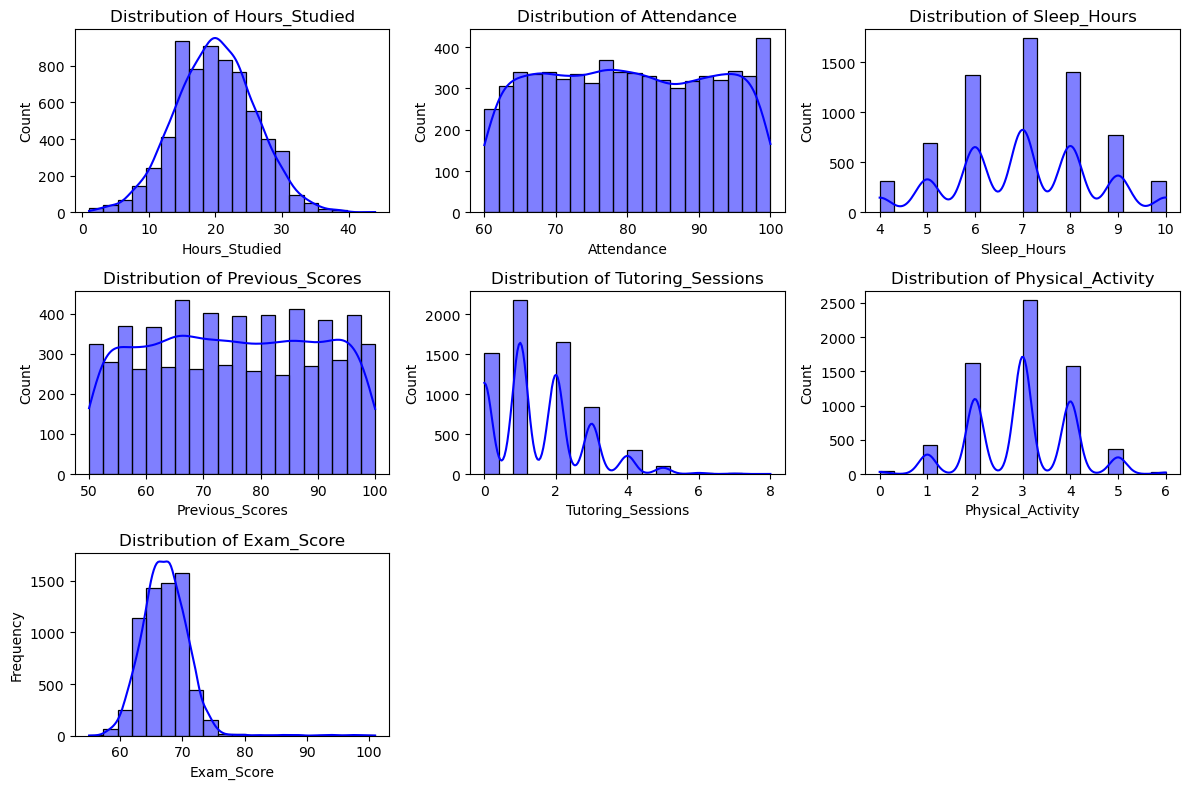

In [79]:
#Graphiques de distribution pour les variables numériques
numerical_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                  'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
plt.figure(figsize=(12, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data[col], kde=True, bins=20, color='blue')
    plt.title(f'Distribution of {col}')
plt.xlabel(col)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

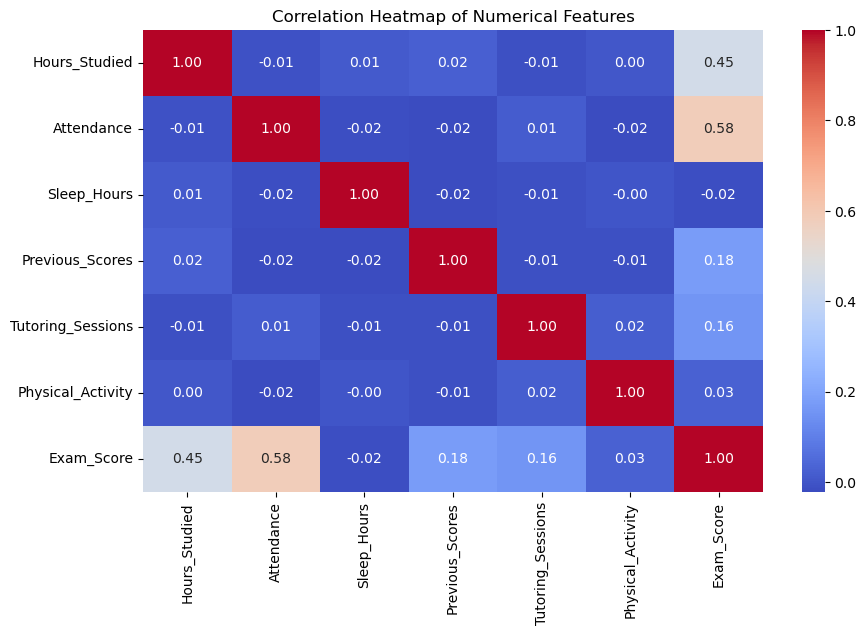

In [80]:
# Select the target variable and numerical features
features = ['Exam_Score','Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                  'Tutoring_Sessions', 'Physical_Activity']
selected_data = data[features]

# Compute the correlation matrix
corr_matrix = selected_data.corr()

# Correlation heatmap for numerical features
plt.figure(figsize=(10, 6))
correlation_matrix = data[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

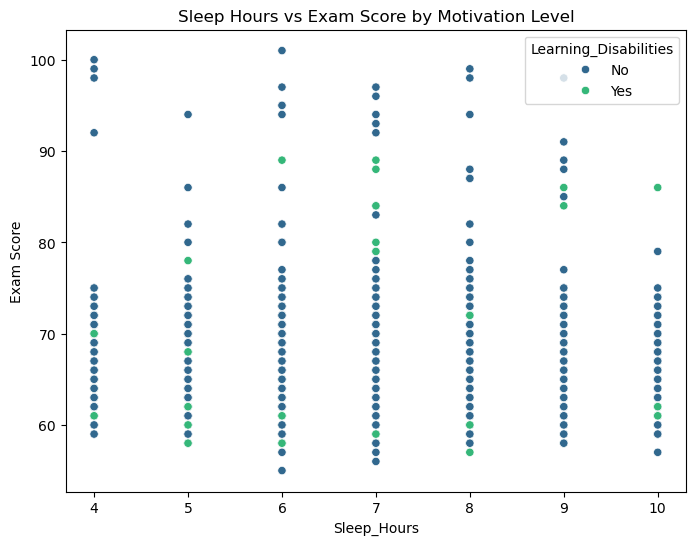

In [81]:
# Scatterplot: Sleep_Hours vs Exam_Score by Learning_Disabilities
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Sleep_Hours', y='Exam_Score', hue='Learning_Disabilities', data=data, palette='viridis')
plt.title("Sleep Hours vs Exam Score by Motivation Level")
plt.xlabel("Sleep_Hours")
plt.ylabel("Exam Score")
plt.legend(title="Learning_Disabilities")
plt.show()

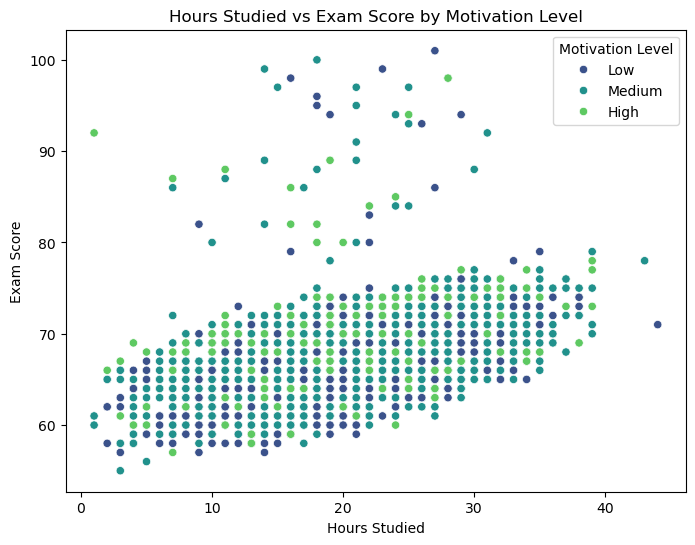

In [82]:
# Scatterplot: Hours_Studied vs Exam_Score by Motivation_Level
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', hue='Motivation_Level', data=data, palette='viridis')
plt.title("Hours Studied vs Exam Score by Motivation Level")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Motivation Level")
plt.show()

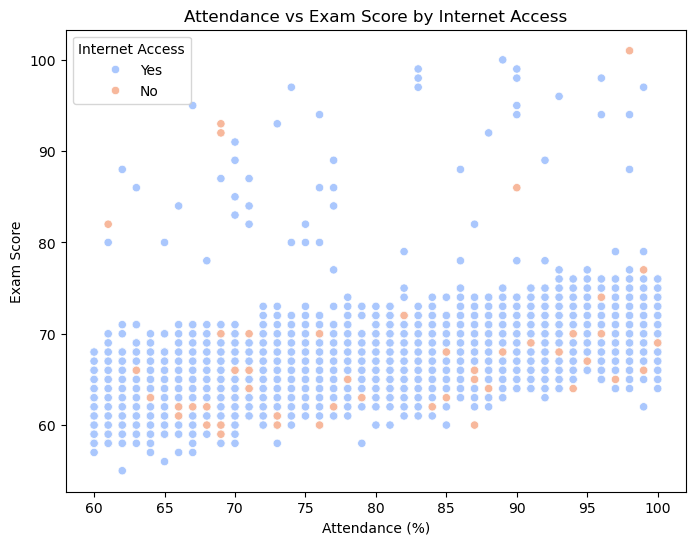

In [83]:
# Scatterplot: Attendance vs Exam_Score by Internet Access
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Attendance', y='Exam_Score', hue='Internet_Access', data=data, palette='coolwarm')
plt.title("Attendance vs Exam Score by Internet Access")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.legend(title="Internet Access")
plt.show()

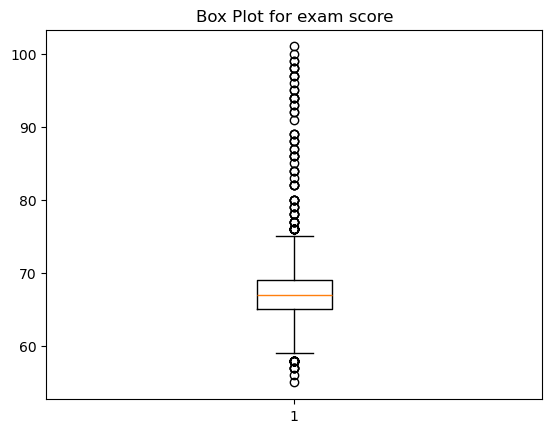

In [84]:
# Box plot for Exam score
import matplotlib.pyplot as plt
plt.boxplot(data['Exam_Score'].dropna())
plt.title('Box Plot for exam score')
plt.show()


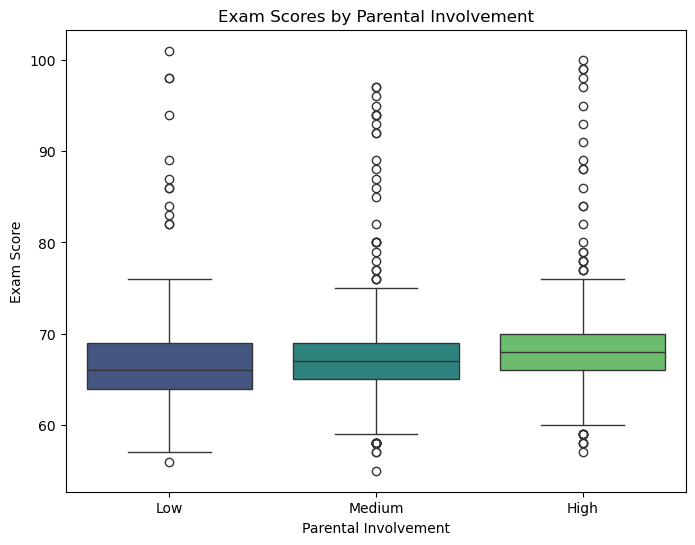

In [85]:
# Boxplot: Exam Scores by Parental Involvement
plt.figure(figsize=(8, 6))
sns.boxplot(x='Parental_Involvement', y='Exam_Score', data=data,hue= 'Parental_Involvement', palette='viridis')
plt.title("Exam Scores by Parental Involvement")
plt.xlabel("Parental Involvement")
plt.ylabel("Exam Score")
plt.show()

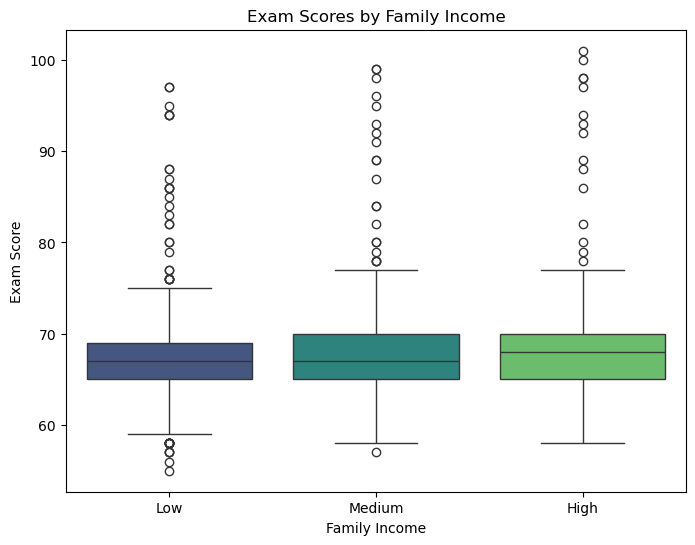

In [86]:
# Boxplot: Exam Scores by Family Income
plt.figure(figsize=(8, 6))
sns.boxplot(x='Family_Income', y='Exam_Score', data=data,hue= 'Family_Income', palette='viridis')
plt.title("Exam Scores by Family Income")
plt.xlabel("Family Income")
plt.ylabel("Exam Score")
plt.show()

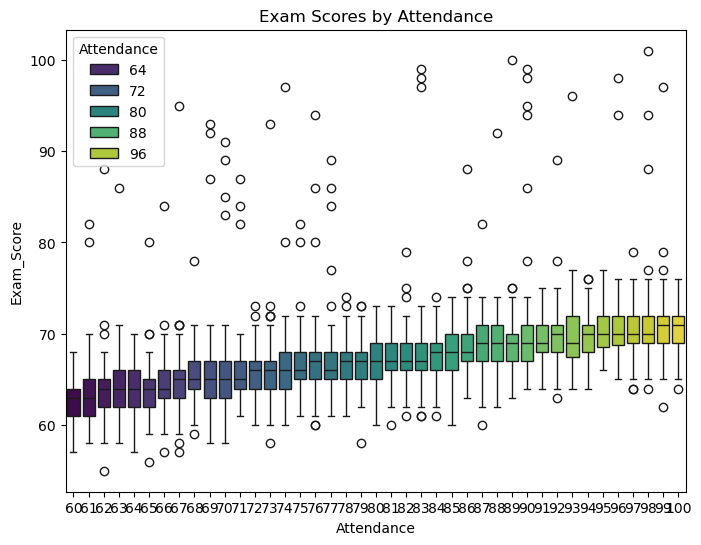

In [87]:
# Boxplot: Exam Scores by Attendance
plt.figure(figsize=(8, 6))
sns.boxplot(x='Attendance', y='Exam_Score', data=data,hue= 'Attendance',palette='viridis')
plt.title("Exam Scores by Attendance")
plt.xlabel("Attendance")
plt.ylabel("Exam_Score")
plt.show()

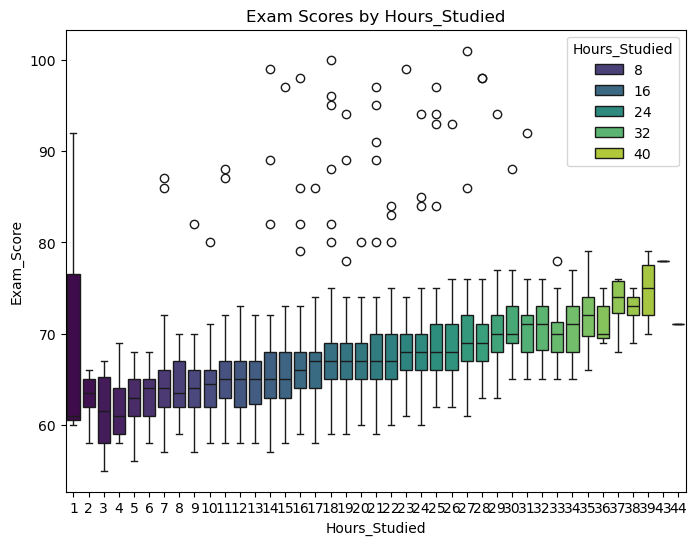

In [88]:
# Boxplot: Exam Scores by Hours_Studied
plt.figure(figsize=(8, 6))
sns.boxplot(x='Hours_Studied', y='Exam_Score', data=data, hue= 'Hours_Studied',palette='viridis')
plt.title("Exam Scores by Hours_Studied")
plt.xlabel("Hours_Studied")
plt.ylabel("Exam_Score")
plt.show()

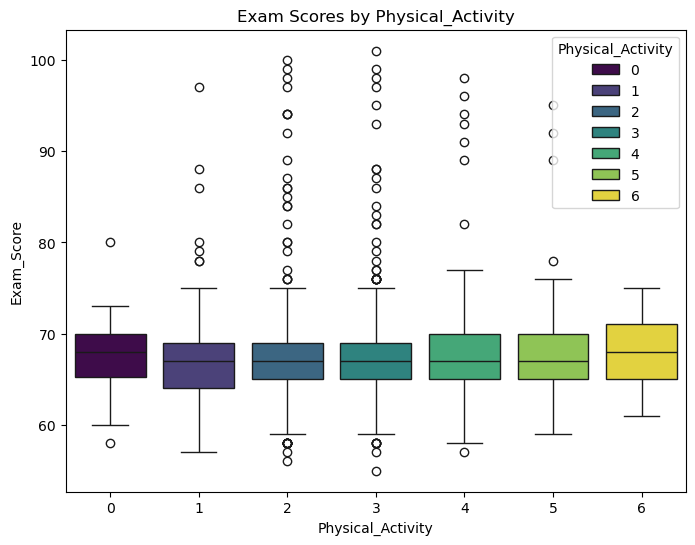

In [89]:
# Boxplot: Exam Scores by hysical_Activity
plt.figure(figsize=(8, 6))
sns.boxplot(x='Physical_Activity', y='Exam_Score', data=data,hue= 'Physical_Activity',palette='viridis')
plt.title("Exam Scores by Physical_Activity")
plt.xlabel("Physical_Activity")
plt.ylabel("Exam_Score")
plt.show()

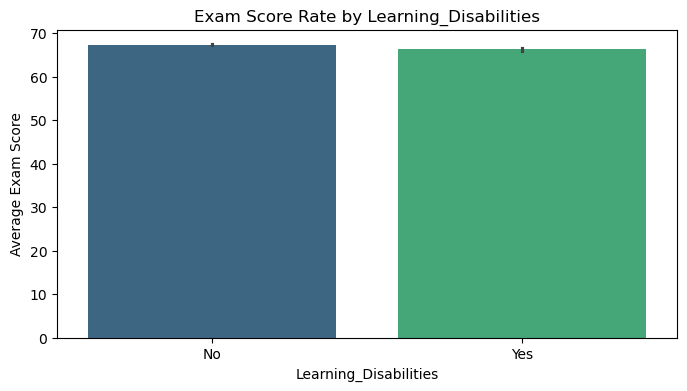

In [90]:
plt.figure(figsize=(8, 4))
sns.barplot(data=data, x='Learning_Disabilities', y='Exam_Score',hue= 'Learning_Disabilities', palette='viridis')
plt.title('Exam Score Rate by Learning_Disabilities')
plt.xlabel('Learning_Disabilities')
plt.ylabel('Average Exam Score')
plt.show()

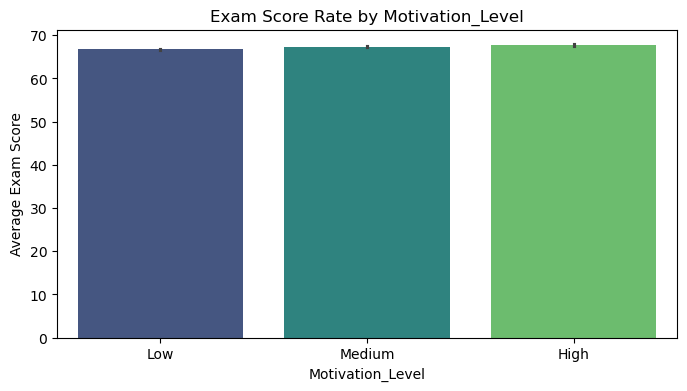

In [91]:
plt.figure(figsize=(8, 4))
sns.barplot(data=data, x='Motivation_Level', y='Exam_Score',hue= 'Motivation_Level',palette='viridis')
plt.title('Exam Score Rate by Motivation_Level')
plt.xlabel('Motivation_Level')
plt.ylabel('Average Exam Score')
plt.show()

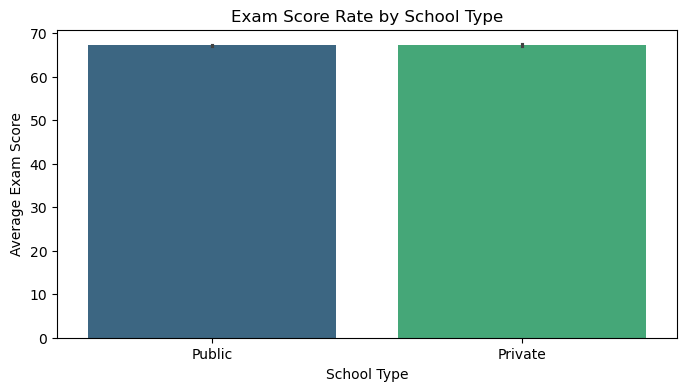

In [92]:
plt.figure(figsize=(8, 4))
sns.barplot(data=data, x='School_Type', y='Exam_Score',hue= 'School_Type',palette='viridis')
plt.title('Exam Score Rate by School Type')
plt.xlabel('School Type')
plt.ylabel('Average Exam Score')
plt.show()

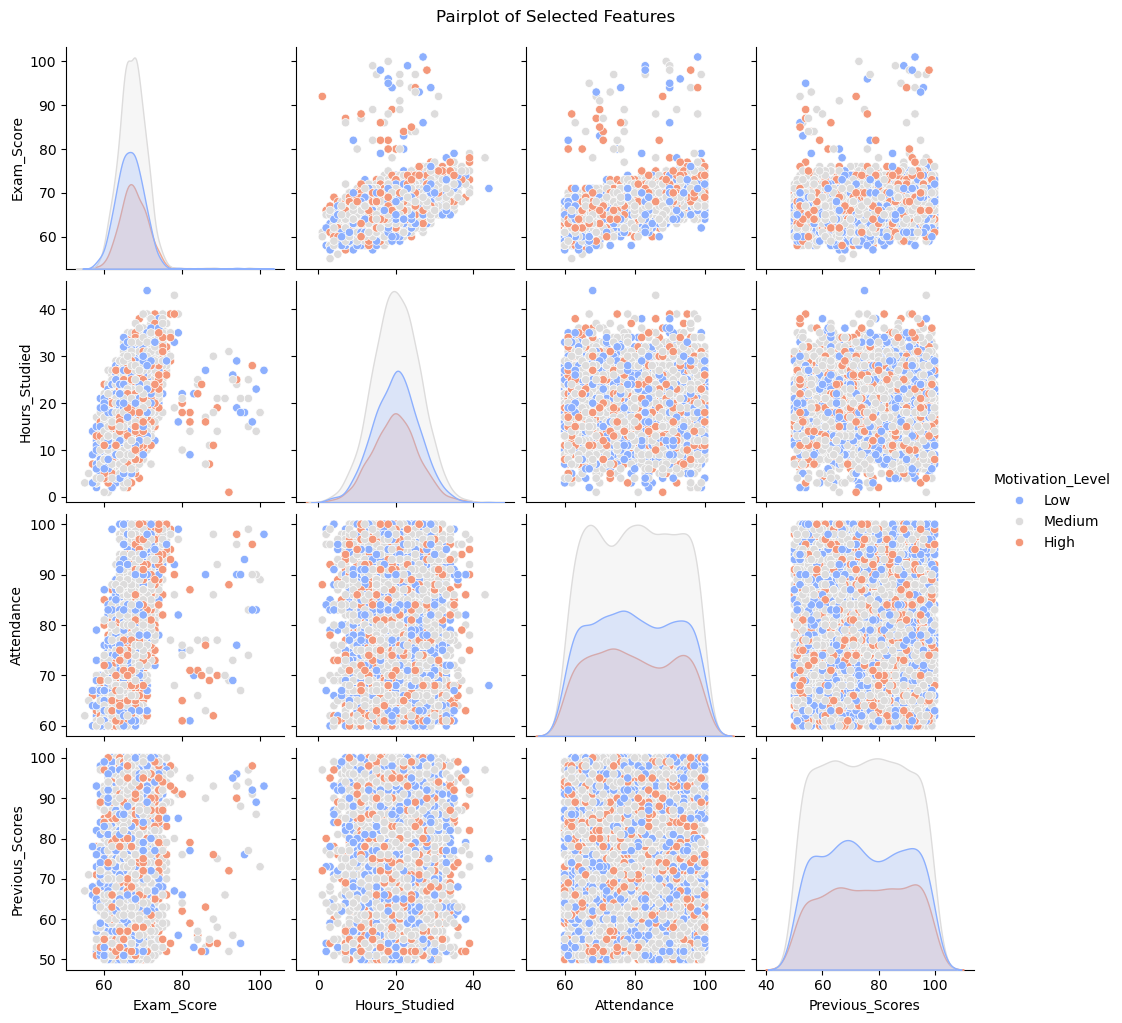

In [93]:
# Prepare data for pairplot
features1 = ['Exam_Score','Hours_Studied', 'Attendance','Previous_Scores']
pairplot_data = data[features1 + ['Motivation_Level']].dropna()

# Create a pairplot
sns.pairplot(pairplot_data, vars=features1, hue='Motivation_Level', palette='coolwarm')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()

In [94]:
# Separate numerical and categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Print the identified columns
print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Numerical Columns: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


In [95]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define the categorical features
categorical_cols = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 
                    'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 
                    'School_Type', 'Peer_Influence', 'Learning_Disabilities', 
                    'Parental_Education_Level', 'Distance_from_Home', 'Gender']

In [96]:
# Initialize the ColumnTransformer with OneHotEncoder
column_transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), categorical_cols)
    ],
    remainder='passthrough'  # Keeps the remaining columns as is
)
# Apply the transformation
data_encoded = column_transformer.fit_transform(data)

# Convert the result to a DataFrame
encoded_feature_names = column_transformer.named_transformers_['encoder'].get_feature_names_out(categorical_cols)
encoded_data = pd.DataFrame(data_encoded, columns=list(encoded_feature_names) + [col for col in data.columns if col not in categorical_cols])

# Save the encoded dataset for inspection
encoded_data.head()

,Parental_Involvement_High,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_High,Access_to_Resources_Low,Access_to_Resources_Medium,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Motivation_Level_High,Motivation_Level_Low,...,Distance_from_Home_Near,Gender_Female,Gender_Male,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,23.0,84.0,7.0,73.0,0.0,3.0,67.0
1,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,19.0,64.0,8.0,59.0,2.0,4.0,61.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,24.0,98.0,7.0,91.0,2.0,4.0,74.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,29.0,89.0,8.0,98.0,1.0,4.0,71.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,19.0,92.0,6.0,65.0,3.0,4.0,70.0


In [97]:
from sklearn.model_selection import train_test_split
X = encoded_data.drop('Exam_Score', axis=1)
#y = encoded_data['Exam_Score']
y = (encoded_data['Exam_Score'] >= encoded_data['Exam_Score'].median()).astype(int)  # Binarisation de la cible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [98]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Initialize the Decision Tree Classifier with default parameters
clf = DecisionTreeClassifier()

# Train the model
clf.fit(X_train, y_train)

# Evaluate the model on the validation set
accuracy = clf.score(X_test, y_test)

# Print results
print("Training complete!")
print(f"Validation Accuracy: {accuracy:.2f}")

Training complete!
Validation Accuracy: 0.85


In [99]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Predict on the validation set
y_pred = clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Validation Accuracy: {accuracy:.2f}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Extract TP, FP, FN, TN from the confusion matrix
TP = conf_matrix[1, 1]  # True Positives
FP = conf_matrix[0, 1]  # False Positives
TN = conf_matrix[0, 0]  # True Negatives
FN = conf_matrix[1, 0]  # False Negatives

print("\nMetrics:")
print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")
print(f"False Negatives (FN): {FN}")

Validation Accuracy: 0.85

Confusion Matrix:
[[457 110]
 [ 94 661]]

Metrics:
True Positives (TP): 661
False Positives (FP): 110
True Negatives (TN): 457
False Negatives (FN): 94


In [100]:
criteria = ['gini', 'entropy', 'log_loss']
# Dictionary to store results
results = {}

for criterion in criteria:
    # Initialize the Decision Tree Classifier with the specific criterion
    clf = DecisionTreeClassifier(criterion=criterion, random_state=42)
    
    # Train the model
    clf.fit(X_train, y_train)
    
    # Compute training accuracy
    train_accuracy = clf.score(X_train, y_train)
    
    # Compute validation accuracy
    val_accuracy = clf.score(X_test, y_test)
    
    # Store results
    results[criterion] = {'Training Accuracy': train_accuracy, 'Validation Accuracy': val_accuracy}

    # Print results for the current criterion
    print(f"Criterion: {criterion}")
    print(f"Training Accuracy: {train_accuracy:.2f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}\n")

# Determine which criterion gives the best validation accuracy
best_criterion = max(results, key=lambda x: results[x]['Validation Accuracy'])
print(f"The best criterion is '{best_criterion}' with a validation accuracy of {results[best_criterion]['Validation Accuracy']:.2f}.")

Criterion: gini
Training Accuracy: 1.00
Validation Accuracy: 0.84

Criterion: entropy
Training Accuracy: 1.00
Validation Accuracy: 0.85

Criterion: log_loss
Training Accuracy: 1.00
Validation Accuracy: 0.85

The best criterion is 'entropy' with a validation accuracy of 0.85.


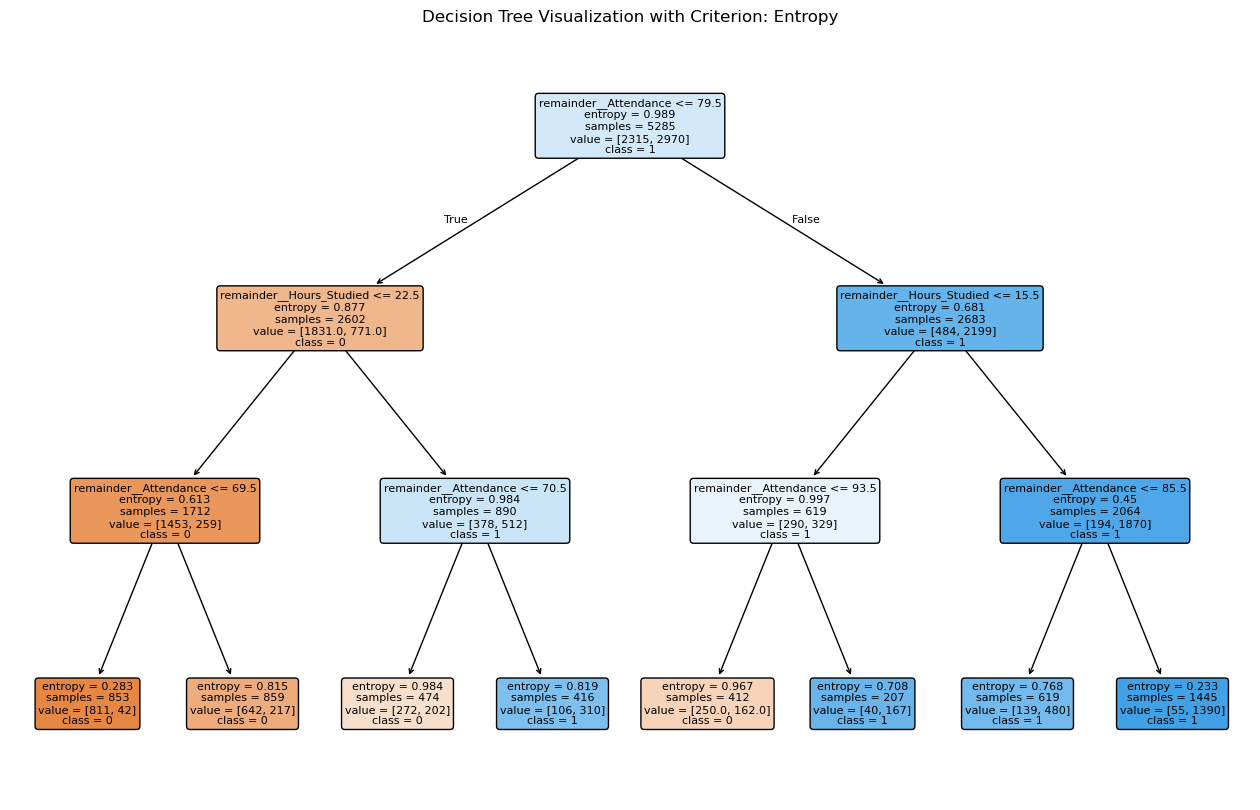

In [101]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree 

# Train a decision tree classifier using 'entropy' as the criterion
clf_viz = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)  # Limit depth for visualization clarity
clf_viz.fit(X_train, y_train)

# Visualize the decision tree
plt.figure(figsize=(16, 10))
plot_tree(
    clf_viz,
    feature_names=column_transformer.get_feature_names_out(),
    class_names=[str(i) for i in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization with Criterion: Entropy")
plt.show()

In [102]:
from dtreeviz import dtreeviz
from dtreeviz import model

C:\Users\hp\miniconda3\envs\datamining\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


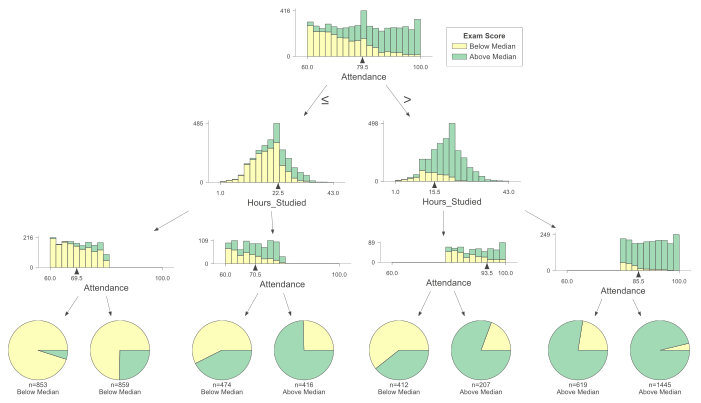

In [103]:
from sklearn.tree import DecisionTreeClassifier
from dtreeviz import model
import IPython.display as display

# Initialiser et entraîner le modèle avec une profondeur limitée
tree_classifier = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)  # Limite à 3 niveaux
tree_classifier.fit(X_train, y_train)

# Générer le modèle de visualisation
viz_model = model(
    tree_classifier,
    X_train=X_train,
    y_train=y_train,
    feature_names=X_train.columns.tolist(),
    target_name="Exam Score",
    class_names=["Below Median", "Above Median"]  # Classes 0 et 1
)

# Afficher la visualisation dans le notebook
svg = viz_model.view()  # Génère la visualisation en format SVG
display.display(svg)  # Afficher directement dans le notebook

In [104]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

In [105]:
# 1. Select features and target
X = encoded_data[['Attendance', 'Hours_Studied']].values  
y = (encoded_data['Exam_Score'] >= encoded_data['Exam_Score'].median()).astype(int)  # Binarisation de la cible

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the SVM
svm_model = SVC(kernel='linear', C=1, random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(C=1, kernel='linear', random_state=42)

In [39]:
# 5. Predict
y_pred = svm_model.predict(X_test_scaled)

# 6. Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")

Confusion Matrix:
 [[716 161]
 [143 963]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82       877
           1       0.86      0.87      0.86      1106

    accuracy                           0.85      1983
   macro avg       0.85      0.84      0.84      1983
weighted avg       0.85      0.85      0.85      1983


Accuracy: 0.85


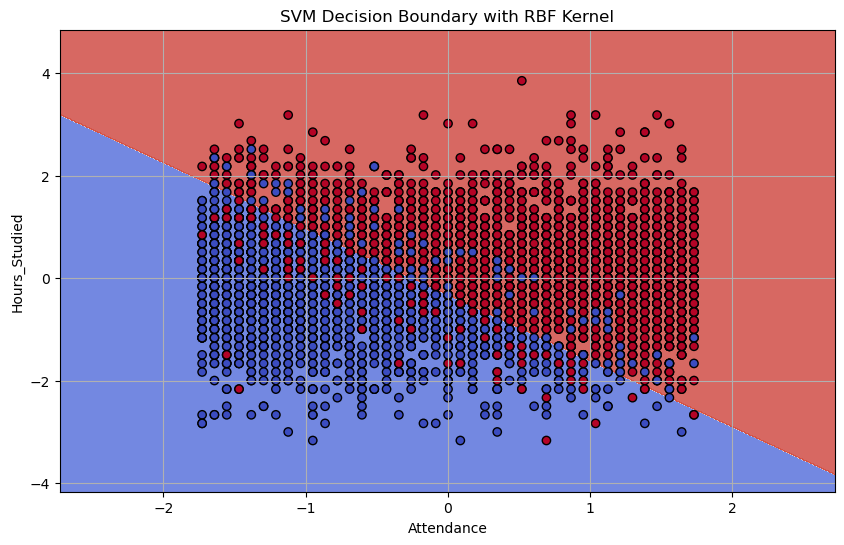

In [40]:
# 7. Visualize decision boundaries (only for 2 features)
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, edgecolor="k", cmap=plt.cm.coolwarm)
plt.title("SVM Decision Boundary with RBF Kernel")
plt.xlabel("Attendance")
plt.ylabel("Hours_Studied")
plt.grid(True)
plt.show()

In [106]:
X = encoded_data[['Sleep_Hours', 'Hours_Studied']].values  
# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Standardize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the SVM
svm_model = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

SVC(C=1, random_state=42)

In [42]:
# 5. Predict
y_pred = svm_model.predict(X_test_scaled)

# 6. Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.2f}")

Confusion Matrix:
 [[444 433]
 [229 877]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.51      0.57       877
           1       0.67      0.79      0.73      1106

    accuracy                           0.67      1983
   macro avg       0.66      0.65      0.65      1983
weighted avg       0.67      0.67      0.66      1983


Accuracy: 0.67


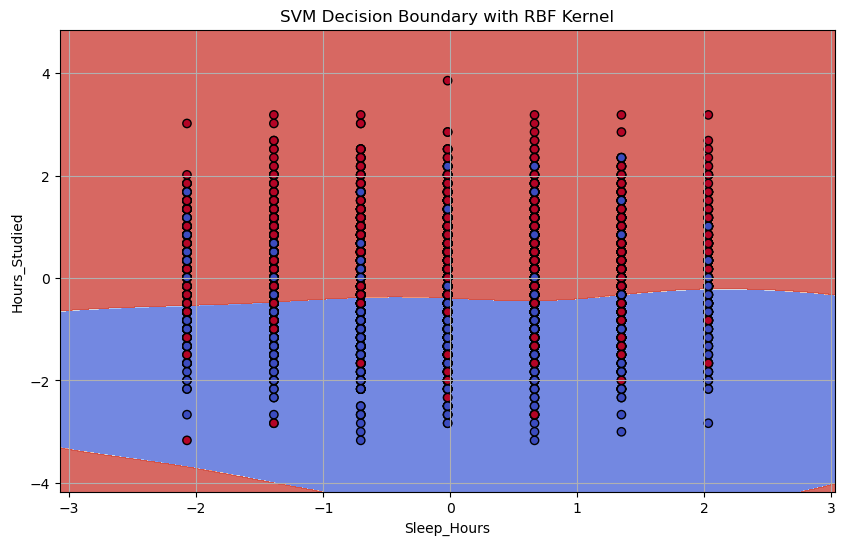

In [40]:
# 7. Visualize decision boundaries (only for 2 features)
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, edgecolor="k", cmap=plt.cm.coolwarm)
plt.title("SVM Decision Boundary with RBF Kernel")
plt.xlabel("Sleep_Hours")
plt.ylabel("Hours_Studied")
plt.grid(True)
plt.show()

In [115]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [116]:
X = encoded_data.drop('Exam_Score', axis=1)
y = (encoded_data['Exam_Score'] >= encoded_data['Exam_Score'].median()).astype(int)

print(len(X), len(y))  

6607 6607


In [118]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Préparation des données numériques
X = encoded_data.drop('Exam_Score', axis=1)  # Features numériques
y = (encoded_data['Exam_Score'] >= encoded_data['Exam_Score'].median()).astype(int)  # Variable cible

# Division en train et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Conversion en tableau NumPy
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

# Entraînement du modèle Naïve Bayes
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [119]:
# Prédiction
y_pred = model.predict(X_test)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_pred, y_test, average="weighted"))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8207261724659607
F1 Score: 0.8228329014782775
Confusion Matrix:
 [[411 156]
 [ 81 674]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.72      0.78       567
           1       0.81      0.89      0.85       755

    accuracy                           0.82      1322
   macro avg       0.82      0.81      0.81      1322
weighted avg       0.82      0.82      0.82      1322



In [120]:
from sklearn.model_selection import GridSearchCV

params = {'alpha': [0.1, 0.5, 1.0]}
grid_search = GridSearchCV(MultinomialNB(), param_grid=params, cv=5)
grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)

Meilleurs paramètres : {'alpha': 0.5}


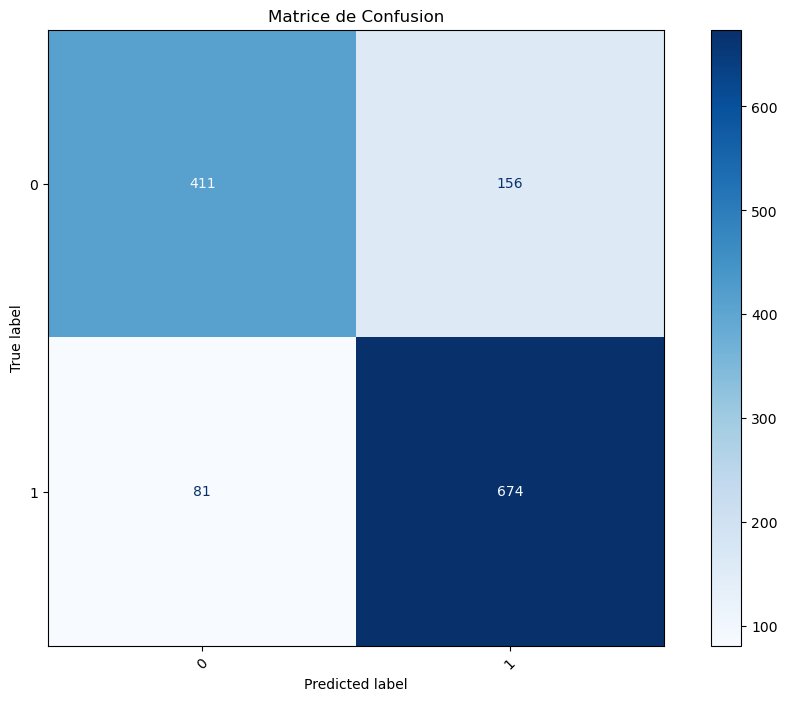

In [121]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Extraire les étiquettes uniques
labels = y_test.unique()

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Affichage de la matrice de confusion
fig, ax = plt.subplots(figsize=(12, 8))  
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
display.plot(ax=ax, cmap='Blues')  # Appliquer une palette de couleurs

# Ajustements supplémentaires
plt.title('Matrice de Confusion')
plt.xticks(rotation=45)  
plt.yticks(rotation=0)   
plt.show()

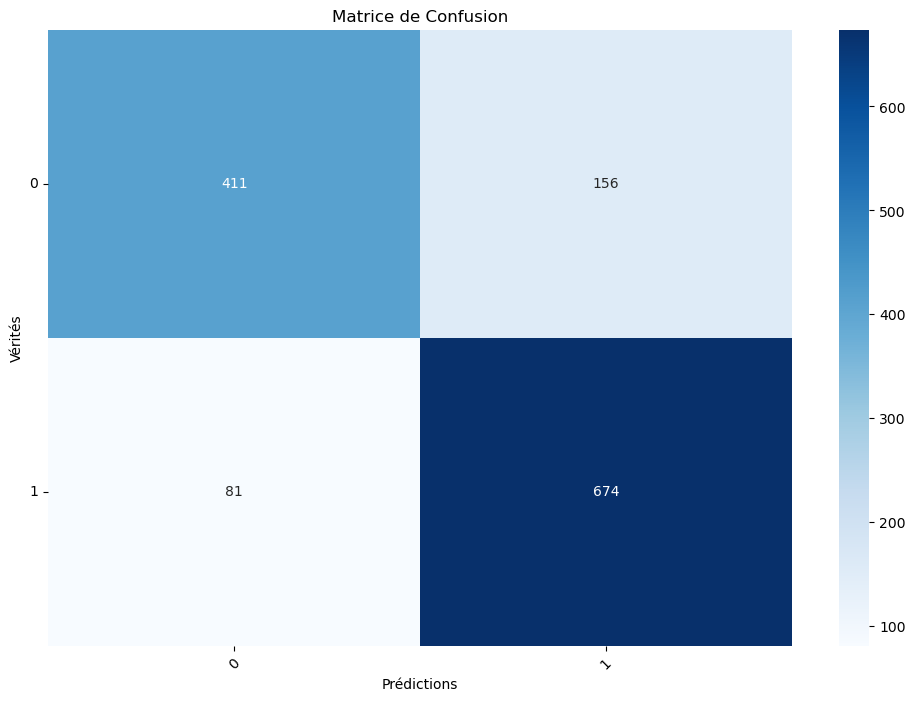

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)

# Ajustement de la taille du graphique
plt.figure(figsize=(12, 8))  # Largeur de 12 et hauteur de 8

# Affichage avec Seaborn
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)

# Titres et étiquettes
plt.title('Matrice de Confusion')
plt.xlabel('Prédictions')
plt.ylabel('Vérités')

# Rotation des étiquettes si nécessaire
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

LogisticRegression(max_iter=1000)

C:\Users\hp\miniconda3\envs\datamining\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names


Accuracy: 0.98
Confusion Matrix:
 [[556  11]
 [ 12 743]]


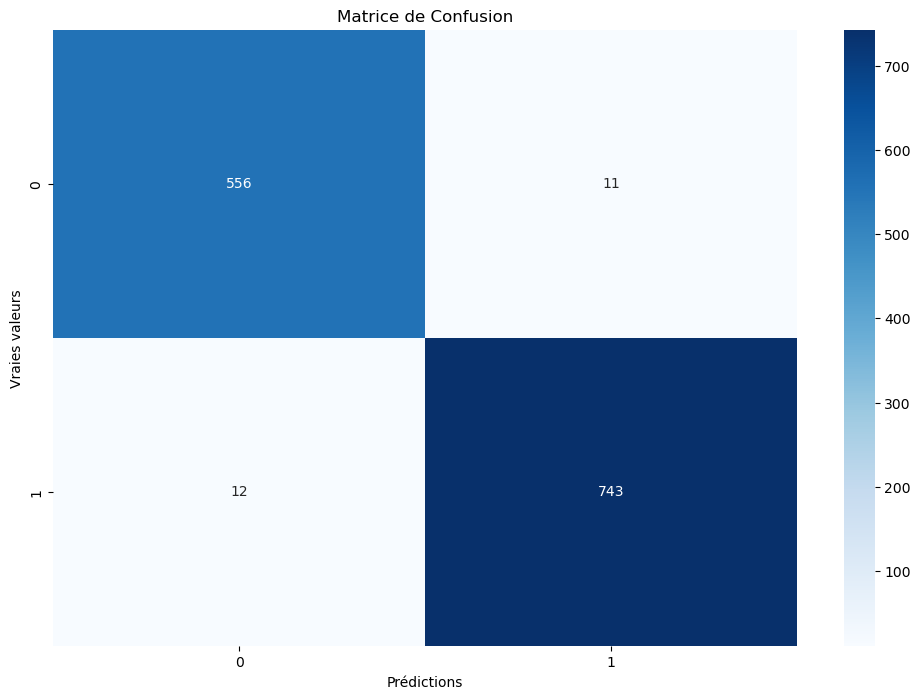

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       567
           1       0.99      0.98      0.98       755

    accuracy                           0.98      1322
   macro avg       0.98      0.98      0.98      1322
weighted avg       0.98      0.98      0.98      1322



In [52]:
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,)
# Prédictions
y_pred = model.predict(X_test)

# Précision du modèle
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.figure(figsize=(12, 8))  # Largeur de 12 et hauteur de 8
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.title('Matrice de Confusion')
plt.ylabel('Vraies valeurs')
plt.xlabel('Prédictions')
plt.show()

# Rapport de classification
print(classification_report(y_test, y_pred))

In [53]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})
print(coefficients.sort_values(by='Coefficient', ascending=False))

                                  Feature  Coefficient
0               Parental_Involvement_High     3.244732
3                Access_to_Resources_High     3.200353
8                   Motivation_Level_High     1.681486
38                      Tutoring_Sessions     1.628213
12                    Internet_Access_Yes     1.589527
23                Peer_Influence_Positive     1.580987
16                   Teacher_Quality_High     1.554162
28  Parental_Education_Level_Postgraduate     1.517501
31                Distance_from_Home_Near     1.504117
13                     Family_Income_High     1.444902
24               Learning_Disabilities_No     1.347029
34                          Hours_Studied     0.968748
7          Extracurricular_Activities_Yes     0.785604
39                      Physical_Activity     0.724605
35                             Attendance     0.653178
37                        Previous_Scores     0.154826
22                 Peer_Influence_Neutral     0.052475
5         

In [54]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print("Précision moyenne en Cross-Validation:", cv_scores.mean())

Précision moyenne en Cross-Validation: 0.9804765564069763


In [55]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [56]:
from sklearn.preprocessing import StandardScaler

# Step 1: Create binary target 'y' based on Exam_Score
exam_score_median = encoded_data['Exam_Score'].median()
encoded_data['Target'] = (encoded_data['Exam_Score'] >= exam_score_median).astype(int)

# Step 2: Separate features (X) and target (y)
X = encoded_data.drop(columns=['Exam_Score', 'Target'])  # Features
y = encoded_data['Target']  # Binary target

# Step 3: Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the shape and structure of the scaled data
X_scaled.shape, y.shape

((6607, 45), (6607,))

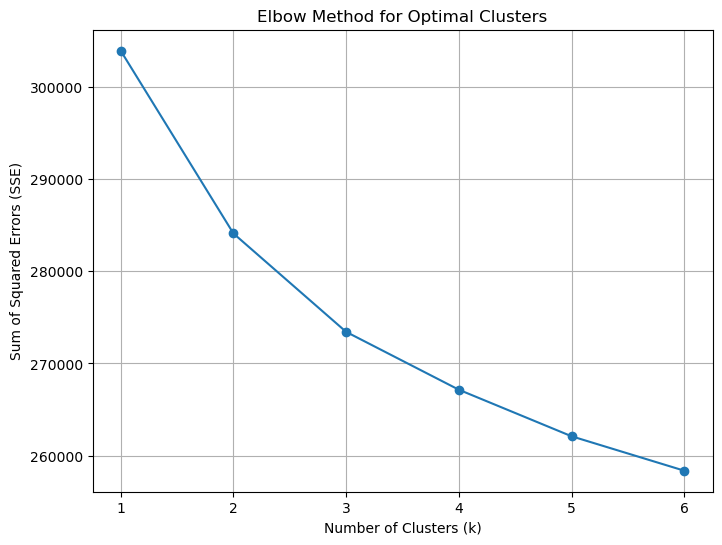

In [122]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 4: Elbow Method to find optimal number of clusters
sse = []
k_range = range(1, 7)  # Testing k from 1 to 7

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, sse, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.grid()
plt.show()

In [ ]:
# Definition de X_subset (necessaire pour le clustering hierarchique et DBSCAN ci-dessous)
# On reprend les 2 variables utilisees dans les visualisations suivantes
X_subset = encoded_data[['Hours_Studied', 'Attendance']]
X_subset_scaled = scaler.fit_transform(X_subset)

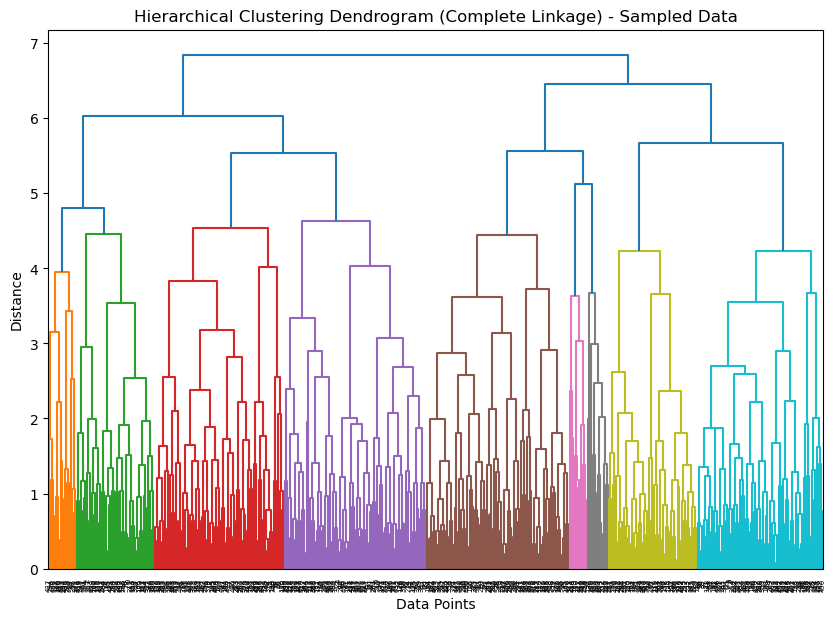

In [59]:
# Step 6: Use a smaller random sample for hierarchical clustering
sampled_data = X_subset.sample(n=500, random_state=42)  # Sample 500 data points

# Scale the sampled data
sampled_data_scaled = scaler.fit_transform(sampled_data)

# Perform hierarchical clustering using complete linkage on the sampled data
linkage_matrix_sampled = linkage(sampled_data_scaled, method='complete')

# Plot the dendrogram for the sampled data
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix_sampled, truncate_mode='level', p=10)  # Truncate for clarity
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage) - Sampled Data")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

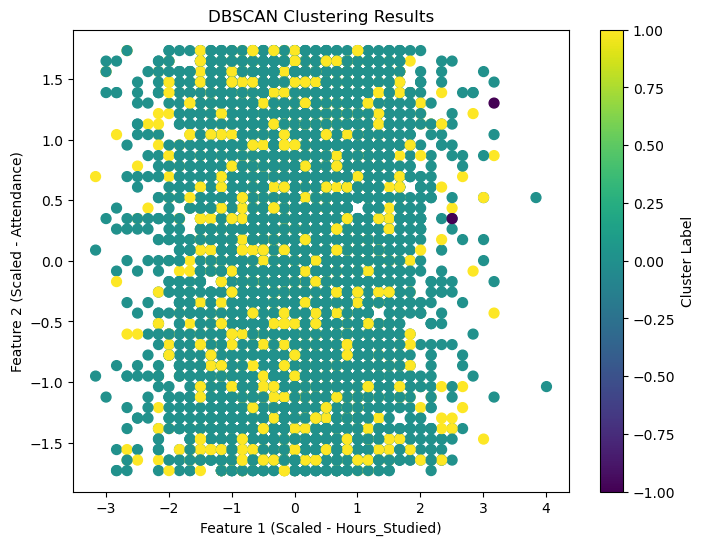

(2, 3)

In [60]:
from sklearn.cluster import DBSCAN

# Step 1: Apply DBSCAN on the full dataset (scaled features)
dbscan = DBSCAN(eps=1.5, min_samples=10)  # Parameters can be adjusted
dbscan_labels = dbscan.fit_predict(X_subset_scaled)

# Step 2: Add the DBSCAN labels to the dataset
encoded_data['DBSCAN_Cluster'] = dbscan_labels

# Step 3: Visualize the DBSCAN clusters using the first two selected features
plt.figure(figsize=(8, 6))
plt.scatter(X_subset_scaled[:, 0], X_subset_scaled[:, 1], c=dbscan_labels, cmap='viridis', s=50)
plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1 (Scaled - Hours_Studied)")
plt.ylabel("Feature 2 (Scaled - Attendance)")
plt.colorbar(label="Cluster Label")
plt.show()

# Display the number of clusters found (excluding noise, labeled as -1)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
n_clusters, n_noise

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

# Step 1: Create the target variable `y`
y = (encoded_data['Exam_Score'] >= encoded_data['Exam_Score'].median()).astype(int)

# Step 2: Drop the target column and scale the data
X = encoded_data.drop(columns=['Exam_Score'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [64]:
# Step 3: Apply PCA to reduce data to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
# Step 5: Apply DBSCAN clustering
dbscan = DBSCAN(eps=1.5, min_samples=5)  # Adjust parameters as needed
dbscan_labels = dbscan.fit_predict(X_scaled)

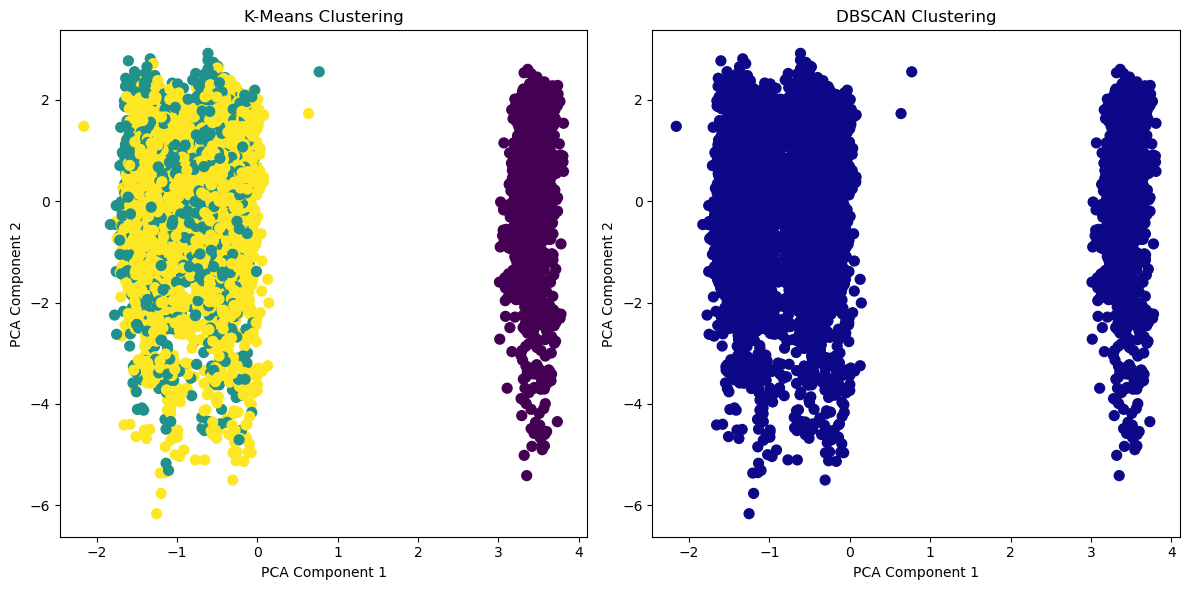

In [66]:
# Visualize K-Means Clusters
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=50)
plt.title('K-Means Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

# Visualize DBSCAN Clusters
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='plasma', s=50)
plt.title('DBSCAN Clustering')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()